# Haiku Cohort Counterfactual — Lung Cancer, every Deceased patient (Deceased → Alive)

**Project Name:** Haiku

## Purpose
- Publication-ready notebook for **Fig. 6e–h** and **Supplementary Fig. 9**
  (Methods 4.5.8, *Population-scale per-patient counterfactual inference*).
- Notebook 12 edits the metadata of **one** lung patient (euj-97851). Here the
  same Deceased → Alive survival edit is repeated **independently for every
  lung cancer patient whose recorded status is Deceased** (n = 71), each
  anchored to the patient's own record:
  `survival_status: dead → Alive`, `survival: m → round(2.4·m)` months, and the
  paired free-text `survival status` string edited consistently.
  The ×2.4 factor is the single-patient edit's own ratio (25 → 60 months).
- Retrieval settings are exactly those of notebook 12: fused H&E + text score
  with `w_he = 0.6`, top-K = 50 against the full mIF atlas (no self-region mask,
  no tissue restriction), with the raw fused scores as neighbour weights.
- The **patient** is the unit of analysis: each patient is reduced to one
  shift per marker, θ<sub>p,m</sub>, and no patch-level P value is computed.

## Steps
1. Load the precomputed atlas (H&E / mIF patch embeddings + per-patch marker positivity) and the cohort.
2. Per-patient counterfactual retrieval → θ<sub>p,m</sub>.
3. Marker QC (53 of 55 channels testable).
4. Patient-level statistics: Wilcoxon signed-rank, BH q, paired d<sub>z</sub>, bootstrap CI (Fig. 6e, Supp. Fig. 9).
5. Hierarchical clustering of the standardized shift vectors (Fig. 6f).
6. Grade 3 vs grade 2 Lasso-logistic regression under nested CV (Fig. 6g,h).

## Notes
- Paths and checkpoints may be environment-specific.
- Run cells top-to-bottom and set your config paths first.
- The analysis logic lives in `downstream/cohort/` (`cohort_counterfactual.py`,
  `cohort_stats.py`, `cohort_plots.py`); this notebook only sets parameters and
  calls it.
- Retrieval for all 71 patients takes well under a minute on one GPU.

## Requirements
- Precomputed Haiku embeddings of the held-out atlas (see `downstream/README.md`,
  *Requirements*), a per-patch marker-positivity matrix row-aligned with them,
  and the region metadata CSVs. These come from the held-out paired atlas and
  are **not** part of `zhihuanglab/Haiku-demo-data`.
- The Haiku weights (`Haiku.from_pretrained("zhihuanglab/Haiku")`) are used only
  to encode the two captions per patient.

In [1]:
import os
import sys
from pathlib import Path

# Notebook lives at <repo>/downstream/ — HAIKU_ROOT points at the repo root.
HAIKU_ROOT = Path.cwd().parent
for p in (HAIKU_ROOT / 'src', HAIKU_ROOT / 'downstream'):
    if str(p) not in sys.path:
        sys.path.append(str(p))

# -------- Fill these in to point at your local copies --------
# (each can also be set through the environment variable of the same name)
EMBEDDINGS_DIR    = Path(os.environ.get('EMBEDDINGS_DIR', '<PATH_TO_PRECOMPUTED_EMBEDDINGS>'))
#   he_embedding.pt, codex_embedding.pt, region_label.pt, region_id_mapping.json
PATCH_LABELS_NPZ  = Path(os.environ.get('PATCH_LABELS_NPZ', '<PATH_TO_PATCH_MARKER_LABELS_NPZ>'))
#   L (N_patches x N_markers, binary positivity, NaN = not measured), markers;
#   rows aligned with the embeddings (see cohort.cohort_counterfactual.build_label_matrix)
METADATA_DIR      = Path(os.environ.get('METADATA_DIR', '<PATH_TO_REGION_METADATA>'))
HAIKU_MODEL       = os.environ.get('HAIKU_MODEL', 'zhihuanglab/Haiku')   # HF repo or local dir
OUTPUT_DIR        = HAIKU_ROOT / 'downstream' / 'cohort_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional: a previously saved effect matrix (.npz with effect / patients / markers).
# If RUN_RETRIEVAL is False the notebook starts from it instead of re-running step 2;
# if RUN_RETRIEVAL is True it is only used as a consistency check.
CACHED_EFFECTS    = os.environ.get('CACHED_EFFECTS') or None
RUN_RETRIEVAL     = True

# -------- Counterfactual edit (Methods 4.5.8) --------
TISSUE            = 'Lung'
EDIT_FIELD        = 'survival_status'
FACTUAL_VALUES    = {'dead', 'deceased'}      # cohort = patients recorded as Deceased
FACTUAL           = 'dead'
COUNTERFACTUAL    = 'Alive'
SURVIVAL_RATIO    = 2.4                       # 25 -> 60 months in the single-patient edit
MIN_PATCHES       = 5
MAX_TEXT_TOKENS   = 200

# -------- Retrieval (identical to notebook 12) --------
W_HE              = 0.6                       # fused score weight on H&E (text gets 0.4)
TOP_K             = 50
WEIGHT_MODE       = 'raw'                     # neighbour weight = fused score s_ij
MASK_SELF         = False                     # query region stays in its gallery
RESTRICT_TISSUE   = None                      # full atlas
DEVICE            = 'cuda'

# -------- Statistics --------
MIN_PATIENTS      = 10                        # channels with fewer finite effects are not tested
QC_MIN_FRAC       = 0.9
QC_SD_FACTOR      = 3.0
N_BOOT            = 2000
N_PERM            = 2000
C_GRID            = (0.02, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0)
SEED              = 0                         # CV splits, bootstrap and permutations
LIBLINEAR_SEED    = 1                         # liblinear coordinate order (see step 6)

from haiku.notebook_utils import setup_notebook, seed_everything
setup_notebook(project_root=str(HAIKU_ROOT))
seed_everything(42)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from cohort import cohort_counterfactual as cc
from cohort import cohort_stats as cs
from cohort import cohort_plots as cp

## 1. Atlas and cohort

The atlas is the held-out set of paired H&E / mIF patches with precomputed
Haiku embeddings. `L[j, m] ∈ {0, 1}` is the positivity annotation of marker *m*
in atlas patch *j* and is NaN when the acquisition did not measure *m*
(`V[j, m] = 0`). The cohort is every lung region whose recorded
`survival_status` is Deceased, so condition 0 is the patient's true state and
condition 1 a genuine counterfactual.

The positivity matrix can be rebuilt from the per-patch label JSONs with
`cc.build_label_matrix(patch_order, label_dir, out_path=...)`, where
`patch_order` is the `(region_id, patch_id)` list in embedding-row order (the
`sample_index` of the dataset used for embedding extraction).

In [3]:
atlas = cc.load_atlas(EMBEDDINGS_DIR, PATCH_LABELS_NPZ)
meta = cc.read_region_metadata(METADATA_DIR, list(atlas['label_of']))
region_tissue = {a: m.get('tissue_type', '') for a, m in meta.items()}
cohort = cc.select_cohort(meta, TISSUE, EDIT_FIELD, FACTUAL_VALUES)

print(f"atlas: {atlas['he'].shape[0]:,} patches / {len(atlas['label_of'])} regions / "
      f"{len(atlas['markers'])} markers")
print(f'cohort: {len(cohort)} {TISSUE} regions recorded as Deceased')
grades = pd.Series([meta[a].get('grade', '') for a in cohort]).value_counts()
print('recorded grade:', dict(grades))

atlas: 51,831 patches / 399 regions / 55 markers
cohort: 71 Lung regions recorded as Deceased
recorded grade: {'3': np.int64(38), '2': np.int64(28), '2--3': np.int64(4), '1': np.int64(1)}


### The paired captions

Two metadata-only captions are built from each patient's own record and differ
only in the survival fields. For the index patient of notebook 12
(euj-97851, 25 months) the counterfactual is exactly the published edit
(Alive, 60 months).

In [4]:
idx = next((a for a in cohort if a.startswith('euj-97851')), cohort[0])
ova, ovb = cc.survival_edit(meta[idx], SURVIVAL_RATIO, EDIT_FIELD, FACTUAL, COUNTERFACTUAL)
print('factual overrides       :', ova)
print('counterfactual overrides:', ovb)
print('\nx0:', cc.caption(meta[idx], ova))
print('\nx1:', cc.caption(meta[idx], ovb))

factual overrides       : {'survival_status': 'dead', 'survival': '25', 'survival status': 'Deceased, 25 mo'}
counterfactual overrides: {'survival_status': 'Alive', 'survival': '60', 'survival status': 'Alive, 60 mo'}

x0: A representative section of Lung tissue highlighting the landscape of Lung Cancer. Additional clinical details include: tissue_type: Lung, diagnosis: Adenocarcinoma, disease: Lung Cancer, type: Malignant, sex: M, age: 68, tnm: T3N1M0, grade: 3, stage: IIIA, survival_status: dead, survival: 25, description: Non-small cell lung carcinoma (NSCLC) tissue array with survival data, including pathology grade, TNM and clinical stage (AJCC 8th ed), 120 cases/120 cores, Pathology diagnosis: Adenocarcinoma, Tissue ID.: Rln211398, survival status: Deceased, 25 mo.

x1: A representative section of Lung tissue highlighting the landscape of Lung Cancer. Additional clinical details include: tissue_type: Lung, diagnosis: Adenocarcinoma, disease: Lung Cancer, type: Malignant, sex: M, 

## 2. Per-patient counterfactual retrieval

For every query patch *i* of patient *p* and each caption *x<sup>k</sup>*, fused
retrieval returns the top-50 mIF neighbours ranked by
*s<sub>ij</sub> = 0.6·cos(h<sub>i</sub>, g<sub>j</sub>) + 0.4·cos(t<sup>k</sup>, g<sub>j</sub>)*,
and the score-weighted prevalence among the neighbours that measured the marker is

$$\nu^{(k)}_{i,m} = \frac{\sum_j s^{(k)}_{ij} L_{j,m}}{\sum_j s^{(k)}_{ij} V_{j,m}}, \qquad
\theta_{p,m} = \frac{1}{|\mathcal I_{p,m}|}\sum_{i \in \mathcal I_{p,m}} \big(\nu^{(1)}_{i,m} - \nu^{(0)}_{i,m}\big).$$

Dividing by the neighbours that measured the marker is what lets acquisitions
with different antibody panels be pooled. Each patient contributes exactly one
value per marker.

In [5]:
if RUN_RETRIEVAL:
    encoder = cc.TextEncoder(HAIKU_MODEL, device=DEVICE, max_length=MAX_TEXT_TOKENS)
    readout = cc.FusedReadout(atlas, w_he=W_HE, top_k=TOP_K, weight_mode=WEIGHT_MODE,
                              mask_self=MASK_SELF, restrict_tissue=RESTRICT_TISSUE,
                              region_tissue=region_tissue, device=DEVICE)
    res = cc.run_cohort(atlas, meta, cohort, encoder, readout, ratio=SURVIVAL_RATIO,
                        field=EDIT_FIELD, factual=FACTUAL, counterfactual=COUNTERFACTUAL,
                        min_patches=MIN_PATCHES, max_length=MAX_TEXT_TOKENS)
    cc.save_effects(res, OUTPUT_DIR / 'perpatient_lung_effects.npz')
    res['provenance'].to_csv(OUTPUT_DIR / 'provenance_lung.csv', index=False)
    E_all = cc.effects_frame(res)
    print(f"\nanalysed {len(E_all)} patients, skipped {len(res['skipped'])}: {res['skipped']}")
    print(f"patches per patient: median {int(np.median(res['n_patches']))}, "
          f"total {int(res['n_patches'].sum()):,}")
    print('\nretrieval provenance (mean over patients):')
    print(res['provenance'].drop(columns=['region']).mean().round(4).to_string())
else:
    E_all = cc.load_effects(CACHED_EFFECTS)
    print(f'loaded cached effect matrix {E_all.shape} (step 2 not re-run)')

Fetching 129 files:   0%|          | 0/129 [00:00<?, ?it/s]

  10/71 patients


  20/71 patients


  30/71 patients


  40/71 patients


  50/71 patients


  60/71 patients


  70/71 patients



analysed 71 patients, skipped 0: []
patches per patient: median 124, total 8,755

retrieval provenance (mean over patients):
n_patches                123.3099
ctrl_self_frac             0.1381
ctrl_n_regions           122.3239
ctrl_same_tissue_frac      0.6818
pert_self_frac             0.1378
pert_n_regions           125.1690
pert_same_tissue_frac      0.6616


In [6]:
# Optional consistency check against a previously saved effect matrix
if RUN_RETRIEVAL and CACHED_EFFECTS:
    ref = cc.load_effects(CACHED_EFFECTS).loc[E_all.index, E_all.columns]
    diff = (E_all - ref).abs().values
    print(f'same patients / markers: True;  max |theta - cached| = {np.nanmax(diff):.2e};  '
          f'corr = {np.corrcoef(np.nan_to_num(E_all.values).ravel(), np.nan_to_num(ref.values).ravel())[0, 1]:.7f}')

same patients / markers: True;  max |theta - cached| = 1.65e-04;  corr = 0.9999998


## 3. Marker QC

Channels with fewer than ten patients contributing a finite effect are not
tested. The matrix QC (used for steps 4–6 alike) keeps channels with a finite
effect in ≥ 90% of patients and drops channels whose across-patient dispersion
exceeds three times the panel median — for lung these are CD16 and CD19,
leaving **53 of 55** channels.

In [7]:
E, dropped = cs.marker_qc(E_all, min_frac=QC_MIN_FRAC, sd_factor=QC_SD_FACTOR)
print(f'{E_all.shape[1]} measured channels -> {E.shape[1]} testable')
for m, why in dropped.items():
    print(f'  dropped {m:6s} {why}')
print('\npatients contributing per channel (min / max):',
      int(E.notna().sum().min()), '/', int(E.notna().sum().max()))

55 measured channels -> 53 testable
  dropped CD16   SD 0.0940 > 3 x median 0.0221
  dropped CD19   SD 0.0970 > 3 x median 0.0221

patients contributing per channel (min / max): 71 / 71


## 4. Patient-level statistics (Fig. 6e, Supplementary Fig. 9)

For each channel, {θ<sub>p,m</sub>}<sub>p</sub> is tested against zero with a
one-sample two-sided Wilcoxon signed-rank test across patients; BH q values are
computed over the 53 tested channels. Within-patient consistency is the paired
effect size *d<sub>z</sub>* = mean / sd, and the 95% CI of the cohort mean comes
from a patient-level bootstrap (B = 2,000).

In [8]:
T = cs.patient_level_tests(E_all, min_patients=MIN_PATIENTS, n_boot=N_BOOT, seed=SEED)
T = T[T.marker.isin(E.columns)].copy()
T['q'] = cs.bh_fdr(T.p_wilcoxon.values)          # BH over the 53 testable channels
T = T.drop(columns='q_BH').sort_values('p_wilcoxon')
T.to_csv(OUTPUT_DIR / 'lung_marker_shifts.csv', index=False)

sig = T[T.q < 0.10]
print(f'{len(T)} channels tested, n = {len(E)} patients')
print(f'q < 0.10: {len(sig)}  ({(sig.mean_delta > 0).sum()} up, {(sig.mean_delta < 0).sum()} down)')
print(f'q < 0.05: {(T.q < 0.05).sum()}')
fmt = {'mean_delta': '{:+.4f}'.format, 'cohens_dz': '{:+.2f}'.format,
       'ci_lo': '{:+.4f}'.format, 'ci_hi': '{:+.4f}'.format,
       'p_wilcoxon': '{:.2e}'.format, 'q': '{:.2e}'.format}
print()
print(sig.to_string(index=False, formatters=fmt))

53 channels tested, n = 71 patients
q < 0.10: 18  (11 up, 7 down)
q < 0.05: 6

     marker  n_patients mean_delta cohens_dz   ci_lo   ci_hi p_wilcoxon        q
        PD1          71    +0.0097     +0.60 +0.0059 +0.0137   1.20e-05 6.36e-04
       CD38          71    +0.0073     +0.36 +0.0028 +0.0120   4.25e-04 1.13e-02
       CD3e          71    +0.0077     +0.41 +0.0035 +0.0121   6.65e-04 1.18e-02
       ICOS          71    +0.0066     +0.47 +0.0036 +0.0101   1.59e-03 1.79e-02
       CD45          71    +0.0088     +0.34 +0.0028 +0.0151   1.69e-03 1.79e-02
       CD79          71    +0.0054     +0.27 +0.0008 +0.0099   4.48e-03 3.96e-02
Keratin8_18          71    -0.0083     -0.36 -0.0143 -0.0032   8.83e-03 6.14e-02
      EpCAM          71    -0.0051     -0.25 -0.0099 -0.0004   9.93e-03 6.14e-02
       CD14          71    +0.0047     +0.33 +0.0013 +0.0080   1.04e-02 6.14e-02
       ECad          71    -0.0081     -0.31 -0.0145 -0.0021   1.33e-02 6.73e-02
        MPO          71    -0.

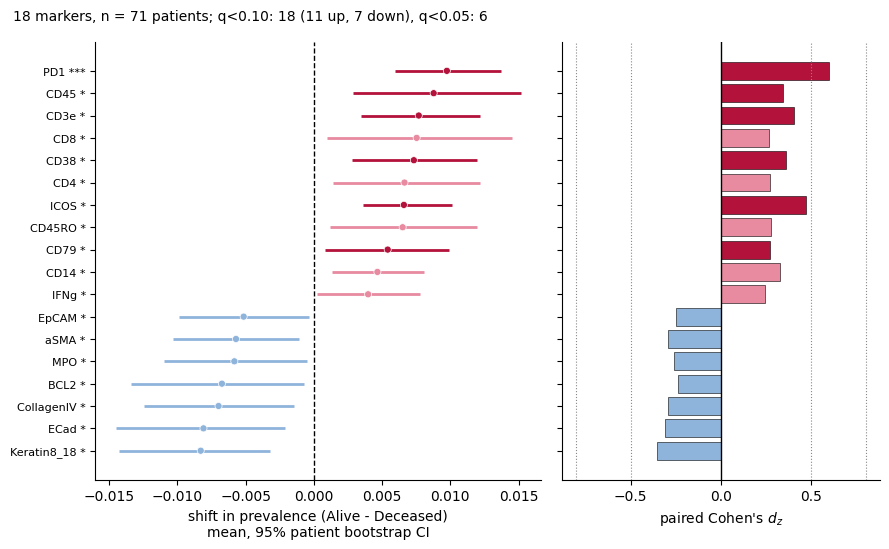

In [9]:
fig = cp.plot_marker_shifts(T, len(E), only_sig=True)        # Fig. 6e
fig.savefig(OUTPUT_DIR / 'fig6e_significant_shifts.pdf', bbox_inches='tight')
plt.show()

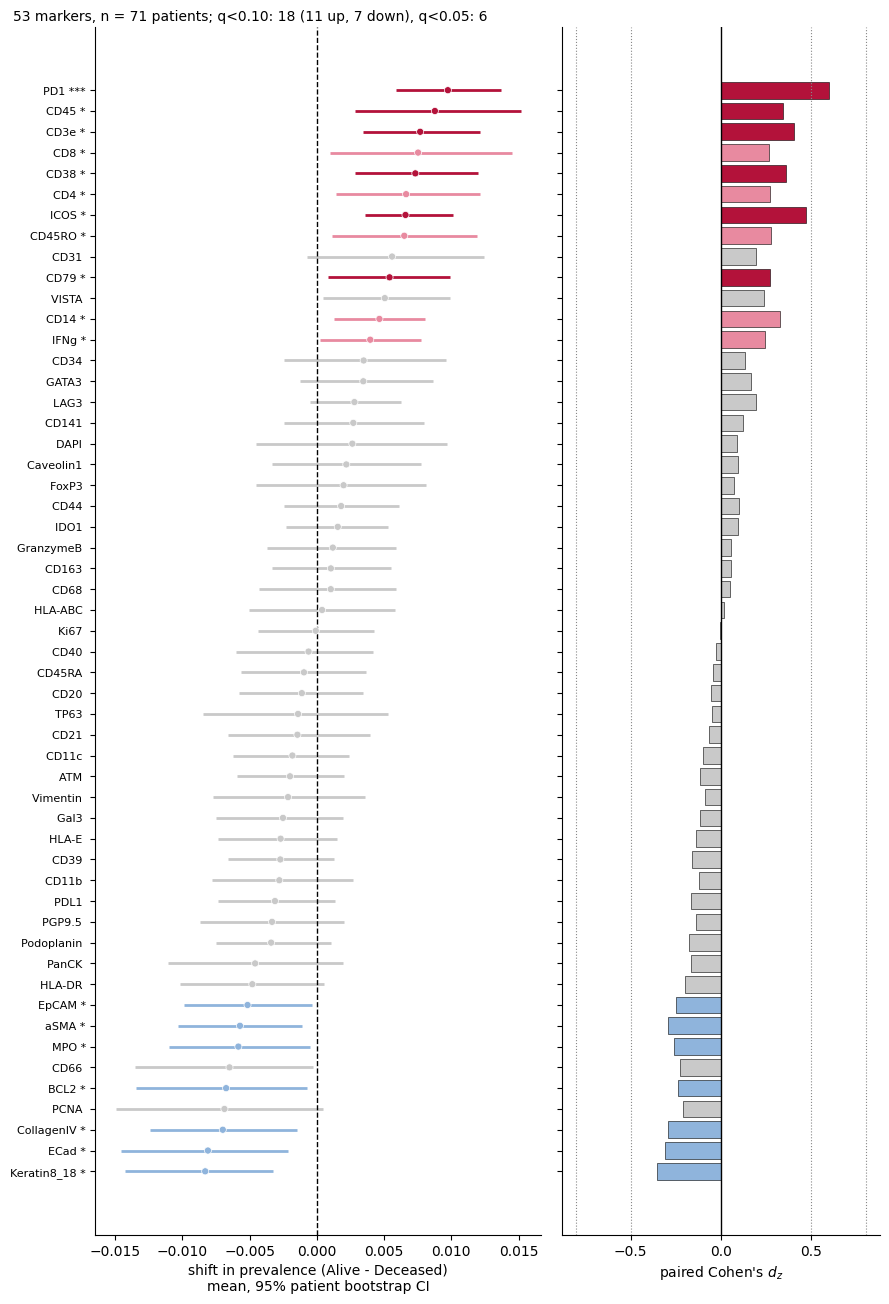

In [10]:
fig = cp.plot_marker_shifts(T, len(E), only_sig=False)       # Supplementary Fig. 9
fig.savefig(OUTPUT_DIR / 'suppfig9_all_shifts.pdf', bbox_inches='tight')
plt.show()

## 5. Hierarchical clustering of the per-patient shift vectors (Fig. 6f)

Each patient is represented by the 53-dimensional vector θ<sub>p</sub>; every
marker is z-scored across all 71 patients (undefined entries set to the marker
mean — this step uses no grade information). Patients and markers are ordered by
average-linkage clustering on correlation distance.

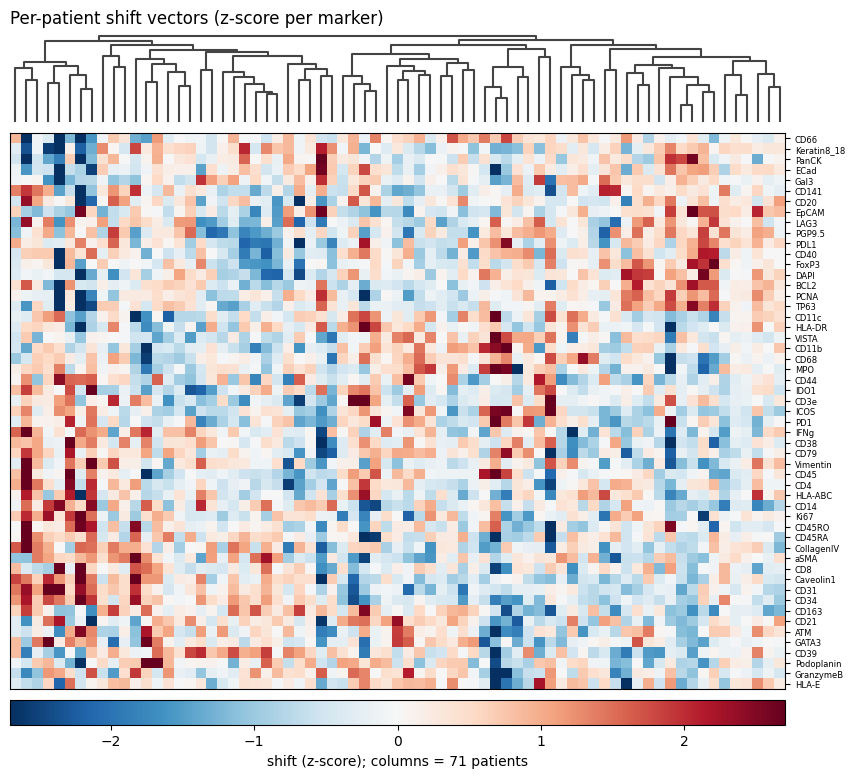

In [11]:
Z = cs.standardize(E)
Zp, Zm, po, mo = cs.cluster_order(Z.values)
fig = cp.plot_clustermap(Z.values, list(Z.columns), Zp, po, mo)
fig.savefig(OUTPUT_DIR / 'fig6f_clustermap.pdf', bbox_inches='tight')
plt.show()

## 6. Tumor grade from the per-patient shift vector (Fig. 6g,h)

The 66 patients with a recorded grade of 2 or 3 enter an ℓ<sub>1</sub>-penalized
logistic regression (grade 3 = positive). An outer stratified 5-fold split holds
out each patient once; inside each training split an inner stratified 3-fold
search picks *C* ∈ {0.02, 0.05, 0.1, 0.25, 0.5, 1, 2} by mean inner AUROC. AUROC
is computed once on the pooled out-of-fold predictions, and P<sub>perm</sub> is
the fraction of 2,000 label permutations (against the fixed predictions)
reaching it. Coefficients, averaged over the outer folds, describe one joint
direction and carry no per-channel P value.

liblinear visits coordinates in a random order. The original analysis left
that order to numpy's global RNG; here it is fixed (`LIBLINEAR_SEED`), and the
cell after the figure shows how much the pooled AUROC moves across seeds.

In [12]:
grade = np.array([meta[a].get('grade', '') for a in Z.index])
keep = np.isin(grade, ['2', '3'])
y = (grade[keep] == '3').astype(int)
print(f'{keep.sum()} of {len(Z)} patients with grade 2/3 ({y.sum()} grade 3, {(1 - y).sum()} grade 2); '
      f'excluded grades: {sorted(set(grade[~keep]))}')

g = cs.grade_classifier(Z.values[keep], y, Cs=C_GRID, outer_folds=5, inner_folds=3,
                        n_perm=N_PERM, seed=SEED, feature_names=Z.columns,
                        liblinear_seed=LIBLINEAR_SEED)
p_txt = f"< {1 / N_PERM:.0e}" if g['p_perm'] == 0 else f"= {g['p_perm']:.4f}"
print(f"pooled out-of-fold AUROC = {g['auroc']:.3f}, P_perm {p_txt}  (C per outer fold: {g['C_chosen']})")

coef = g['coef'][g['coef'].abs() > 1e-8].sort_values(ascending=False)
coef.rename('mean_coef').to_csv(OUTPUT_DIR / 'lung_grade_lasso_coefficients.csv')
print(f'\n{len(coef)}/{len(g["coef"])} non-zero coefficients')
print('toward grade 3:', ', '.join(f'{m} ({v:+.2f})' for m, v in coef.head(7).items()))
print('toward grade 2:', ', '.join(f'{m} ({v:+.2f})' for m, v in coef.tail(7)[::-1].items()))

66 of 71 patients with grade 2/3 (38 grade 3, 28 grade 2); excluded grades: [np.str_('1'), np.str_('2--3')]


pooled out-of-fold AUROC = 0.815, P_perm < 5e-04  (C per outer fold: [2.0, 2.0, 2.0, 1.0, 2.0])

42/53 non-zero coefficients
toward grade 3: Podoplanin (+2.15), DAPI (+1.05), Keratin8_18 (+1.01), Caveolin1 (+0.97), GATA3 (+0.95), CD31 (+0.81), PCNA (+0.51)
toward grade 2: CollagenIV (-0.89), CD38 (-0.85), aSMA (-0.66), CD3e (-0.40), CD45RA (-0.36), CD79 (-0.19), BCL2 (-0.16)


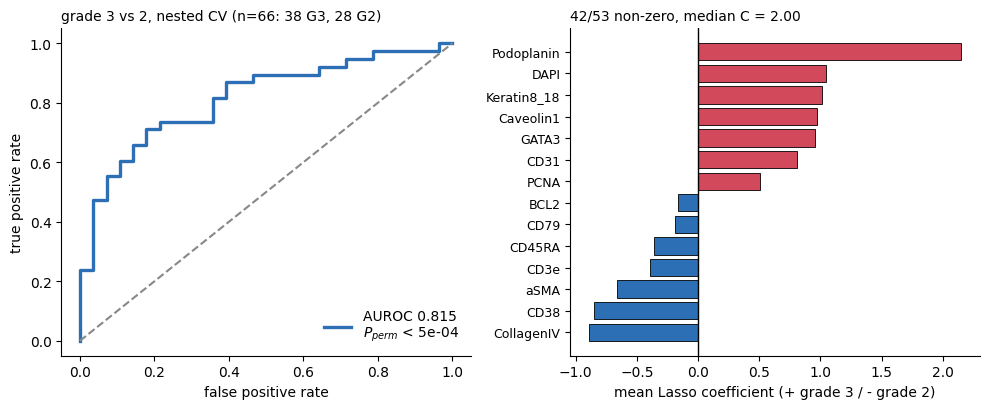

In [13]:
fig = cp.plot_grade_classifier(g)
fig.savefig(OUTPUT_DIR / 'fig6gh_grade_classifier.pdf', bbox_inches='tight')
plt.show()

In [14]:
# Sensitivity of the pooled AUROC to liblinear's coordinate order
# (CV splits fixed; only the liblinear seed changes)
seed_auc = pd.Series({s: cs.grade_classifier(Z.values[keep], y, Cs=C_GRID, n_perm=0, seed=SEED,
                                             liblinear_seed=s)['auroc'] for s in range(20)})
print(f'pooled OOF AUROC over 20 liblinear seeds: min {seed_auc.min():.3f}, '
      f'median {seed_auc.median():.3f}, max {seed_auc.max():.3f}')
print(seed_auc.round(3).value_counts().sort_index().to_string())

pooled OOF AUROC over 20 liblinear seeds: min 0.805, median 0.815, max 0.816
0.805     1
0.806     2
0.814     3
0.815    12
0.816     2


## Summary vs. manuscript

Expected (manuscript): 71 patients; 53 testable channels; 18 markers at q < 0.10
(11 up, 7 down), 6 at q < 0.05; PD-1 d<sub>z</sub> ≈ +0.60, q ≈ 6.4 × 10⁻⁴;
grade classifier n = 66 (38 grade 3, 28 grade 2), out-of-fold AUROC 0.81,
P<sub>perm</sub> < 5 × 10⁻⁴; grade-3 weights led by podoplanin, keratin 8/18,
caveolin-1, GATA3, CD31, DAPI and grade-2 weights by collagen IV, CD38, α-SMA.

In [15]:
pd1 = T.set_index('marker').loc['PD1']
summary = pd.DataFrame([
    ('patients', len(E), 71),
    ('testable channels', E.shape[1], 53),
    ('q < 0.10 (up / down)', f'{len(sig)} ({(sig.mean_delta > 0).sum()} / {(sig.mean_delta < 0).sum()})', '18 (11 / 7)'),
    ('q < 0.05', int((T.q < 0.05).sum()), 6),
    ('PD-1 d_z', f'{pd1.cohens_dz:+.2f}', '+0.60'),
    ('PD-1 q', f'{pd1.q:.1e}', '6.4e-04'),
    ('grade n (G3 / G2)', f'{len(y)} ({y.sum()} / {(1 - y).sum()})', '66 (38 / 28)'),
    ('grade AUROC', f"{g['auroc']:.3f}", '0.81'),
    ('grade P_perm', p_txt, '< 5e-04'),
], columns=['quantity', 'this run', 'manuscript'])
summary.to_csv(OUTPUT_DIR / 'summary_vs_manuscript.csv', index=False)
summary

,quantity,this run,manuscript
0,patients,71,71
1,testable channels,53,53
2,q < 0.10 (up / down),18 (11 / 7),18 (11 / 7)
3,q < 0.05,6,6
4,PD-1 d_z,+0.60,+0.60
5,PD-1 q,6.4e-04,6.4e-04
6,grade n (G3 / G2),66 (38 / 28),66 (38 / 28)
7,grade AUROC,0.815,0.81
8,grade P_perm,< 5e-04,< 5e-04
